# Semana 14: Storytelling de Datos - AutoTec

## Contexto comercial

AutoTec es un proyecto de análisis del mercado de vehículos usados en Chile.  
El objetivo es transformar los datos obtenidos mediante scraping, limpieza, EDA y modelos en información útil para la toma de decisiones.

La pregunta principal del análisis es:

**¿Qué variables influyen más en el precio de un vehículo usado y cómo pueden apoyar decisiones comerciales?**gicas.

In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("S14_Storytelling_AutoTec").getOrCreate()

In [4]:
from dotenv import load_dotenv
import os

load_dotenv()

uri = os.getenv("MONGO_URI")

df = spark.read.format("mongodb") \
    .option("connection.uri", uri) \
    .option("database", "proyecto_bigdata") \
    .option("collection", "Contenedor_Autos_Limpio") \
    .load()

print("Registros cargados:", df.count())
df.printSchema()
df.show(5)

Registros cargados: 1988
root
 |-- _id: string (nullable = true)
 |-- antiguedad_auto: integer (nullable = true)
 |-- cat_combustible: integer (nullable = true)
 |-- categoria_precio: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- combustible: string (nullable = true)
 |-- es_ecologico: integer (nullable = true)
 |-- fecha_captura: string (nullable = true)
 |-- foto_url: string (nullable = true)
 |-- grupo: string (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- marca: string (nullable = true)
 |-- modelo: string (nullable = true)
 |-- precio: double (nullable = true)
 |-- rango_kilometraje: string (nullable = true)
 |-- tipo_marca: string (nullable = true)
 |-- url: string (nullable = true)
 |-- uso_anual_estimado: double (nullable = true)
 |-- usuario: string (nullable = true)
 |-- year: integer (nullable = true)

+--------------------+---------------+---------------+----------------+--------+-----------+------------+-------------------+--------+

In [5]:
import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt

df_limpio = df.select(
    F.col("marca"),
    F.col("modelo"),
    F.col("year").cast("int").alias("year"),
    F.col("precio").cast("double").alias("precio"),
    F.col("kilometraje").cast("double").alias("kilometraje"),
    F.col("combustible"),
    F.col("ciudad")
).dropna(subset=["marca", "year", "precio"])

df_limpio = df_limpio.withColumn(
    "antiguedad_auto",
    F.lit(2026) - F.col("year")
)

print("Registros limpios:", df_limpio.count())
df_limpio.show(5)

Registros limpios: 1988
+-----+--------------------+----+-------+-----------+-----------+--------+---------------+
|marca|              modelo|year| precio|kilometraje|combustible|  ciudad|antiguedad_auto|
+-----+--------------------+----+-------+-----------+-----------+--------+---------------+
| audi|A1 Sportback 30 T...|2024|2.199E7|    27294.0|    bencina|santiago|              2|
| audi|A3 2.0 Tfsi Sport...|2018|1.899E7|    84917.0|    bencina|santiago|              8|
| audi|A3 1.4 35 Tfsi St...|2018|1.589E7|    93687.0|    bencina|santiago|              8|
| audi|A1 Sportback 30 T...|2024|2.199E7|    11766.0|    bencina|santiago|              2|
| audi|        A6 2.0 Turbo|2015|1.297E7|   182000.0|     diesel|santiago|             11|
+-----+--------------------+----+-------+-----------+-----------+--------+---------------+
only showing top 5 rows



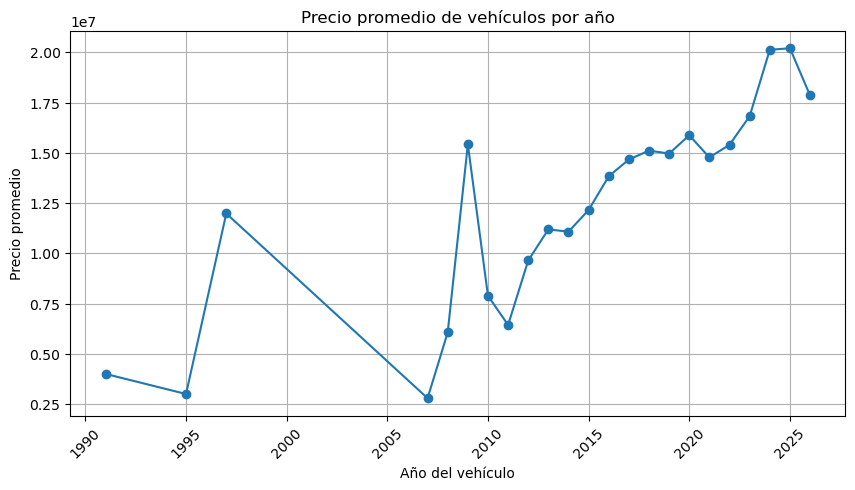

In [6]:
precio_anio = df_limpio.groupBy("year") \
    .agg(F.round(F.avg("precio"), 0).alias("precio_promedio")) \
    .orderBy("year")

precio_anio_pd = precio_anio.toPandas()

plt.figure(figsize=(10,5))
plt.plot(precio_anio_pd["year"], precio_anio_pd["precio_promedio"], marker="o")
plt.title("Precio promedio de vehículos por año")
plt.xlabel("Año del vehículo")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Interpretación

El gráfico muestra que los vehículos más recientes tienden a presentar precios promedio más altos. Esto confirma que el año del vehículo es una variable relevante para explicar el valor comercial y la depreciación del mercado automotriz usado.

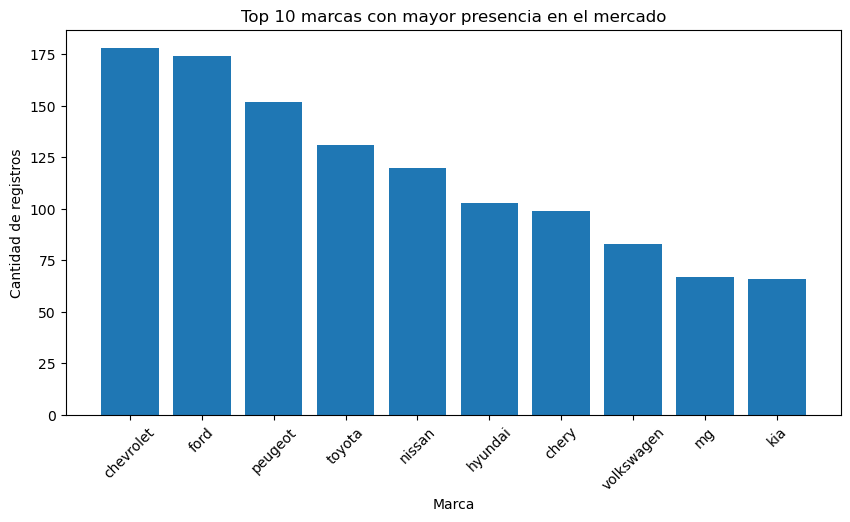

In [7]:
top_marcas = df_limpio.groupBy("marca") \
    .agg(F.count("*").alias("cantidad")) \
    .orderBy(F.desc("cantidad")) \
    .limit(10)

top_marcas_pd = top_marcas.toPandas()

plt.figure(figsize=(10,5))
plt.bar(top_marcas_pd["marca"], top_marcas_pd["cantidad"])
plt.title("Top 10 marcas con mayor presencia en el mercado")
plt.xlabel("Marca")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.show()

### Interpretación

El gráfico muestra las marcas con mayor cantidad de registros dentro del mercado analizado. Esto permite identificar qué marcas tienen mayor presencia en la oferta de vehículos usados.

Desde una mirada de negocio, una mayor cantidad de registros puede indicar mayor disponibilidad, rotación o participación dentro del mercado automotriz. Esta información ayuda a reconocer cuáles son las marcas más relevantes para el análisis comercial de AutoTec.

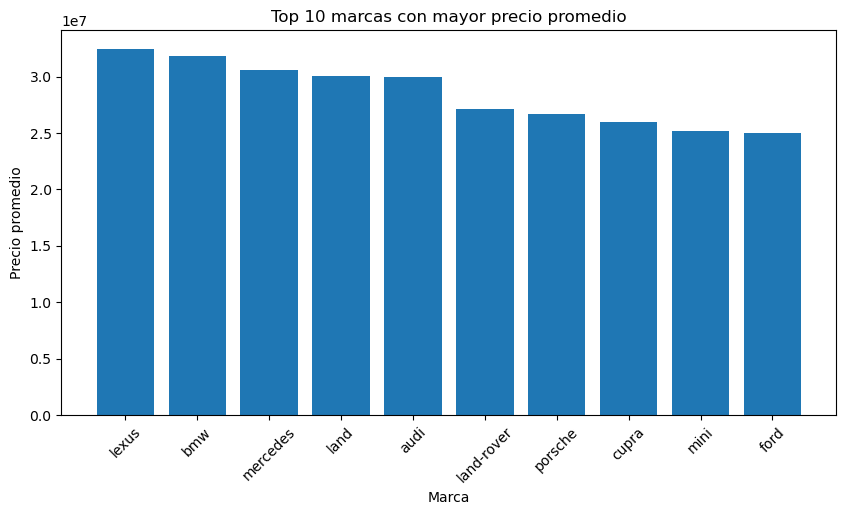

In [8]:
precio_marca = df_limpio.groupBy("marca") \
    .agg(F.round(F.avg("precio"), 0).alias("precio_promedio")) \
    .orderBy(F.desc("precio_promedio")) \
    .limit(10)

precio_marca_pd = precio_marca.toPandas()

plt.figure(figsize=(10,5))
plt.bar(precio_marca_pd["marca"], precio_marca_pd["precio_promedio"])
plt.title("Top 10 marcas con mayor precio promedio")
plt.xlabel("Marca")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45)
plt.show()

### Interpretación

El análisis del precio promedio por marca permite identificar diferencias importantes en el valor comercial de los vehículos. Algunas marcas mantienen precios significativamente más altos que otras, lo que puede estar asociado a factores como reputación, equipamiento, demanda y percepción de calidad.

Este resultado permite segmentar el mercado entre marcas de gama alta y marcas de mayor masividad, entregando información útil para procesos de tasación, evaluación comercial y análisis competitivo.



Las bandas de competitividad permiten observar la dispersión de precios entre distintas marcas. Las marcas con una diferencia más amplia entre precio mínimo y máximo presentan una mayor variabilidad en el mercado, mientras que aquellas con rangos más estrechos muestran una oferta más homogénea.

Este análisis facilita la identificación de segmentos premium y masivos, apoyando decisiones de valoración, negociación y posicionamiento comercial.ivo.

In [9]:
df_limpio.printSchema()

root
 |-- marca: string (nullable = true)
 |-- modelo: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- precio: double (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- combustible: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- antiguedad_auto: integer (nullable = true)



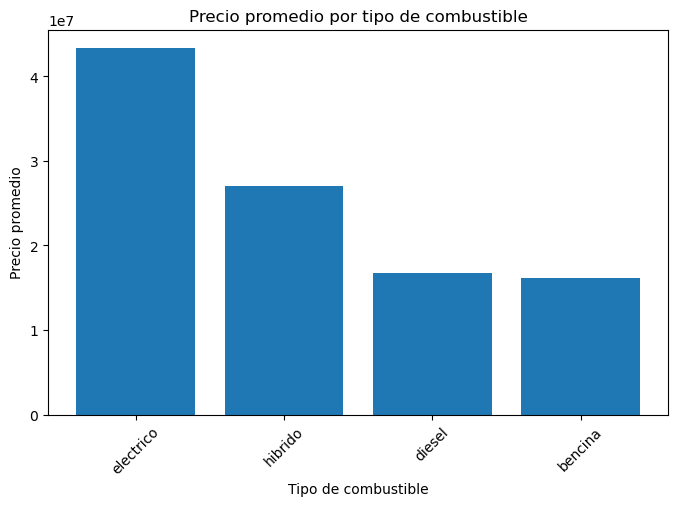

In [10]:
precio_combustible = df_limpio.groupBy("combustible") \
    .agg(F.round(F.avg("precio"), 0).alias("precio_promedio")) \
    .orderBy(F.desc("precio_promedio"))

precio_combustible_pd = precio_combustible.toPandas()

plt.figure(figsize=(8,5))
plt.bar(precio_combustible_pd["combustible"], precio_combustible_pd["precio_promedio"])
plt.title("Precio promedio por tipo de combustible")
plt.xlabel("Tipo de combustible")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45)
plt.show()

### Interpretación

El gráfico permite comparar el precio promedio de los vehículos según su tipo de combustible. Esta información ayuda a identificar si existen segmentos con mayor valor comercial, como vehículos diésel, híbridos, eléctricos o bencineros.

Desde una perspectiva de negocio, este indicador permite reconocer qué tipo de combustible se asocia a precios más altos y puede apoyar decisiones de compra, venta y segmentación del mercado automotriz usado.

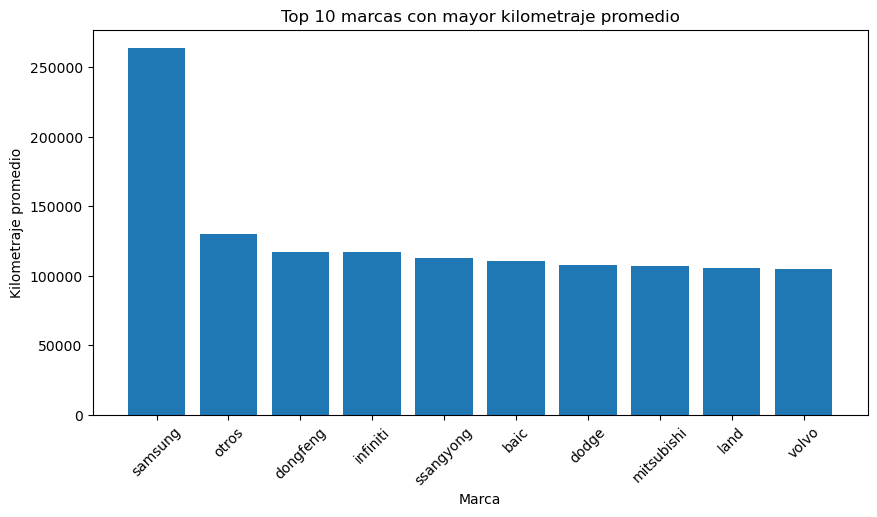

In [11]:
km_marca = df_limpio.groupBy("marca") \
    .agg(F.round(F.avg("kilometraje"), 0).alias("kilometraje_promedio")) \
    .orderBy(F.desc("kilometraje_promedio")) \
    .limit(10)

km_marca_pd = km_marca.toPandas()

plt.figure(figsize=(10,5))
plt.bar(km_marca_pd["marca"], km_marca_pd["kilometraje_promedio"])
plt.title("Top 10 marcas con mayor kilometraje promedio")
plt.xlabel("Marca")
plt.ylabel("Kilometraje promedio")
plt.xticks(rotation=45)
plt.show()

### Interpretación

El kilometraje promedio por marca permite identificar el nivel de uso que presentan los vehículos disponibles en el mercado. Un mayor kilometraje suele estar asociado a un mayor desgaste mecánico y puede influir negativamente en el precio de venta.

Este indicador complementa el análisis del precio, ya que permite entender si ciertas marcas mantienen su valor a pesar de presentar mayores niveles de uso, aportando información relevante para procesos de tasación y evaluación comercial.

In [12]:
total_registros = df_limpio.count()

kpi_estrategico = df_limpio.groupBy("marca") \
    .agg(
        F.count("*").alias("cantidad_registros")
    ) \
    .withColumn(
        "participacion_porcentaje",
        F.round(
            (F.col("cantidad_registros") / total_registros) * 100,
            2
        )
    ) \
    .orderBy(F.desc("cantidad_registros"))

kpi_estrategico.show(10, False)

+----------+------------------+------------------------+
|marca     |cantidad_registros|participacion_porcentaje|
+----------+------------------+------------------------+
|chevrolet |178               |8.95                    |
|ford      |174               |8.75                    |
|peugeot   |152               |7.65                    |
|toyota    |131               |6.59                    |
|nissan    |120               |6.04                    |
|hyundai   |103               |5.18                    |
|chery     |99                |4.98                    |
|volkswagen|83                |4.18                    |
|mg        |67                |3.37                    |
|kia       |66                |3.32                    |
+----------+------------------+------------------------+
only showing top 10 rows



In [13]:
kpi_tactico = df_limpio.groupBy("marca") \
    .agg(
        F.round(F.avg("precio"), 0).alias("precio_promedio"),
        F.round(F.avg("kilometraje"), 0).alias("kilometraje_promedio"),
        F.count("*").alias("cantidad")
    ) \
    .orderBy(F.desc("precio_promedio"))

kpi_tactico.show(10, False)

+----------+---------------+--------------------+--------+
|marca     |precio_promedio|kilometraje_promedio|cantidad|
+----------+---------------+--------------------+--------+
|lexus     |3.2471E7       |85743.0             |10      |
|bmw       |3.1775854E7    |75431.0             |41      |
|mercedes  |3.06144E7      |89513.0             |25      |
|land      |3.001625E7     |105706.0            |8       |
|audi      |2.9957105E7    |61728.0             |38      |
|land-rover|2.7156667E7    |81120.0             |3       |
|porsche   |2.6676E7       |104033.0            |5       |
|cupra     |2.599E7        |32450.0             |2       |
|mini      |2.516E7        |40211.0             |7       |
|ford      |2.4979799E7    |73605.0             |174     |
+----------+---------------+--------------------+--------+
only showing top 10 rows



In [14]:
registros_originales = df.count()
registros_validos = df_limpio.count()
registros_eliminados = registros_originales - registros_validos

print("Registros originales:", registros_originales)
print("Registros válidos:", registros_validos)
print("Registros eliminados:", registros_eliminados)

Registros originales: 1988
Registros válidos: 1988
Registros eliminados: 0


# Matriz de Indicadores para la Toma de Decisiones

Los indicadores obtenidos a partir del análisis permiten apoyar distintos niveles de decisión dentro de una organización.

## Nivel Estratégico

| KPI | Objetivo |
|-------|---------|
| Participación de mercado por marca | Identificar las marcas dominantes |
| Precio promedio general | Comprender el comportamiento global del mercado |
| Antigüedad promedio de vehículos | Analizar tendencias de renovación |

## Nivel Táctico

| KPI | Objetivo |
|-------|---------|
| Precio promedio por marca | Comparar posicionamiento comercial |
| Precio promedio por combustible | Identificar segmentos de mayor valor |
| Kilometraje promedio por marca | Evaluar desgaste promedio de la oferta |

## Nivel Operacional

| KPI | Objetivo |
|-------|---------|
| Registros capturados | Monitorear el proceso de scraping |
| Registros válidos | Controlar calidad de datos |
| Registros eliminados | Detectar inconsistencias en la información |

# Principales Hallazgos

1. El año del vehículo tiene una influencia directa sobre el precio de mercado, observándose una tendencia de mayor valor en vehículos más recientes.

2. Existen diferencias significativas entre marcas, tanto en cantidad de oferta disponible como en precio promedio.

3. El tipo de combustible genera variaciones importantes en el valor comercial de los vehículos.

4. El kilometraje continúa siendo un factor relevante para explicar diferencias de precio entre vehículos similares.

5. La calidad de los datos obtenidos permite generar indicadores útiles para apoyar decisiones comerciales y estratégicas.

# Recomendaciones

A partir de los resultados obtenidos se recomienda:

- Priorizar el análisis de vehículos más recientes debido a su mayor valor comercial.
- Considerar el kilometraje como variable crítica en procesos de valoración y tasación.
- Monitorear las marcas con mayor participación de mercado para detectar oportunidades comerciales.
- Utilizar los indicadores desarrollados como base para sistemas de monitoreo continuo del mercado automotriz.
- Incorporar dashboards interactivos para facilitar la visualización y seguimiento de los KPIs.

# Conclusión

El análisis realizado permitió transformar una gran cantidad de datos obtenidos mediante técnicas de Big Data en información útil para la toma de decisiones.

Los resultados muestran que variables como el año del vehículo, la marca, el kilometraje y el tipo de combustible influyen directamente en el comportamiento de los precios dentro del mercado automotriz usado.

La construcción de indicadores estratégicos, tácticos y operacionales permitió estructurar la información desde distintas perspectivas organizacionales, facilitando la identificación de tendencias y oportunidades de negocio.

Finalmente, el trabajo desarrollado establece una base sólida para la construcción de tableros interactivos en la siguiente etapa del proyecto, permitiendo visualizar los indicadores de manera dinámica y apoyar procesos de decisión basados en datos.